# Faithfulness Task 15-9 Complete — MoRF/Random/LeRF + AUPC/CI/Stats (ID 24-28)

> **Workstream:** Faithfulness | **Tasks 24-28** | **Requires Retrain: No** | **1 notebook giai het 5 task**
> **NGUYEN TAC: TUYET DOI KHONG MOCK/DEMO/DUMMY — 100% data & checkpoint that**
> **Checkpoint that:** `output Training/checkpoints_dqn_comparison3primary/ckpt-50` (DQN) va `output Training/outputA2Cmod/checkpoints_a2cmod/ckpt-64` (A2C_mod)
> **Data that:** `data/test.tfrecords` (504 steps), `data/capacity.tfrecords`, `data/stock.tfrecords` via `TFRecordDataset`
> **SHAP ranking that:** `Ablation_Study/output/topk_shap_full_results_660.csv` (tu `topk_shap_analysis.ipynb` PartitionExplainer) — fallback recompute neu mismatch
> File moi, khong sua 3 notebook cu trong `Ablation_Study/faithfulness/`

## Experimental Protocol (Task 26) — Giao thuc that
- **Agents:** DQN (MultiProductQNetwork, hidden auto-detect 32/128) ckpt-50 va A2C_mod (Actor+Critic) ckpt-64
- **State:** 660-dim = [inventory 0:220, sales 220:440, waste 440:660], waste=0.025*inventory, 14 actions [0,0.005,0.01,0.0125,0.015,0.0175,0.02,0.03,0.04,0.08,0.12,0.2,0.5,1]
- **Scenarios:** EASY {sales_scale 0.5, waste_rate 0.010}, MEDIUM {1.0,0.025}, HARD {1.5,0.050}
- **States:** 50 states/scenario x 3 =150/agent, tong 300. Tao tu `test.tfrecords` 50 steps dau *scale + x_init, waste
- **Masking:** k=1..10 (0.15%-1.52% cua 660), replacement = `median(background_660)` voi background 100 (uniform+clip)
- **Repeated runs:** MoRF/LeRF deterministic 1 lan/state, Random B=30 bootstrap per state, majority vote ASR>15/30, seed 42
- **Metric that:** delta_q=(orig[a*]-masked[a*])/(|orig[a*]|+1e-8), delta_pi=pi_orig[a*]-pi_masked[a*], ASR, AUPC=trapz(curve,1..10)

## Threshold dinh nghia (Task 27)
- **Meaningful Q-drop:** relative >1% (tuong duong 2 buoc action toi thieu 0.5%), hoac absolute pi >0.01
- **Action flip:** argmax_masked != argmax_orig (ASR)
- Bien minh: action_space granularity 0.005, waste 0.025, Q~0.8 nen 1% vuot nhieu


In [1]:
# Cell 0: Setup — KHONG MOCK, chi dung thu vien that va path that
import os, warnings, time, json, pathlib, sys
import numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy.stats import wilcoxon, ttest_rel, kruskal
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)
sns.set_style('whitegrid')
print('TF', tf.__version__, 'Devices', tf.config.list_physical_devices())

# --- PATH THAT — tu dong tim REPO_ROOT ---
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p/'data'/'test.tfrecords').exists():
            return p
    # fallback truc tiep
    cand = Path(r'C:\GitHub\Q-learning-for-Inventory-Management')
    if cand.exists(): return cand
    return start
REPO = find_repo_root()
print('REPO', REPO)
DATA_DIR = REPO/'data'
TEST_FILE = str(DATA_DIR/'test.tfrecords')
CAP_FILE = str(DATA_DIR/'capacity.tfrecords')
STOCK_FILE = str(DATA_DIR/'stock.tfrecords')
DQN_CKPT_DIR = str(REPO/'output Training'/'checkpoints_dqn_comparison3primary')
A2C_CKPT_DIR = str(REPO/'output Training'/'outputA2Cmod'/'checkpoints_a2cmod')
CSV_PATH = str(REPO/'Ablation_Study'/'output'/'topk_shap_full_results_660.csv')
OUT_DIR = REPO/'Ablation_Study'/'output'
OUT_DIR.mkdir(exist_ok=True, parents=True)
TASK_OUT = REPO/'Feedback 7-9'/'task15-9'/'output'
TASK_OUT.mkdir(exist_ok=True, parents=True)
for p in [TEST_FILE, CAP_FILE, STOCK_FILE, DQN_CKPT_DIR, A2C_CKPT_DIR, CSV_PATH]:
    print(('OK' if Path(p).exists() else 'MISSING'), p)


TF 2.20.0 Devices [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
REPO c:\GitHub\Q-learning-for-Inventory-Management
OK c:\GitHub\Q-learning-for-Inventory-Management\data\test.tfrecords
OK c:\GitHub\Q-learning-for-Inventory-Management\data\capacity.tfrecords
OK c:\GitHub\Q-learning-for-Inventory-Management\data\stock.tfrecords
OK c:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary
OK c:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod
OK c:\GitHub\Q-learning-for-Inventory-Management\Ablation_Study\output\topk_shap_full_results_660.csv


In [2]:
# Cell 1: Config that — giong Training/DQN.ipynb va A2C-mod.ipynb
NUM_PRODUCTS=220; NUM_FEATURES_PP=3; NUM_FEATURES=660; NUM_ACTIONS=14
ACTION_SPACE=np.array([0,0.005,0.01,0.0125,0.015,0.0175,0.02,0.03,0.04,0.08,0.12,0.2,0.5,1], dtype=np.float32)
WASTE_RATE=0.025; GAMMA=0.99; DROPOUT=0.1
NUM_TEST_STATES=50; NUM_BG_SAMPLES=100; TOP_K_MAX=10; NUM_BOOTSTRAP=30
SCENARIOS={'EASY':{'sales_scale':0.5,'waste_rate':0.010},'MEDIUM':{'sales_scale':1.0,'waste_rate':0.025},'HARD':{'sales_scale':1.5,'waste_rate':0.050}}
SCENARIO_ORDER=['EASY','MEDIUM','HARD']; AGENTS=['DQN','A2C_mod']
MEANINGFUL_REL_Q=0.01; MEANINGFUL_ABS_PI=0.01
print(SCENARIOS)


{'EASY': {'sales_scale': 0.5, 'waste_rate': 0.01}, 'MEDIUM': {'sales_scale': 1.0, 'waste_rate': 0.025}, 'HARD': {'sales_scale': 1.5, 'waste_rate': 0.05}}


In [3]:
# Cell 2: Model classes THAT — copy tu shap_faithfulness_random_baseline_test.ipynb:158-271, khong mock
class Dense(tf.Module):
    def __init__(self, in_dim, out_dim, name=None):
        super().__init__(name=name)
        self.w=tf.Variable(tf.random.truncated_normal([in_dim,out_dim], stddev=1.0), name='w')
        self.b=tf.Variable(tf.zeros([out_dim]), name='b')
    def __call__(self, x): return tf.matmul(x, self.w)+self.b

class Actor(tf.Module):
    def __init__(self, hidden=32, name='actor'):
        super().__init__(name=name)
        self.l1=Dense(3,hidden); self.l2=Dense(hidden,hidden); self.l3=Dense(hidden,hidden); self.l4=Dense(hidden,14)
        self.hidden=hidden
    def __call__(self, x, training=False):
        h=tf.nn.relu(self.l1(x))
        if training: h=tf.nn.dropout(h, rate=DROPOUT)
        h=tf.nn.relu(self.l2(h))
        if training: h=tf.nn.dropout(h, rate=DROPOUT)
        h=tf.nn.relu(self.l3(h))
        if training: h=tf.nn.dropout(h, rate=DROPOUT)
        logits=self.l4(h)
        return tf.nn.softmax(logits)

class Critic(tf.Module):
    def __init__(self, hidden=32, name='critic'):
        super().__init__(name=name)
        self.l1=Dense(3,hidden); self.gn=tf.keras.layers.GroupNormalization(groups=1, axis=-1); self.l2=Dense(hidden,1)
        self.hidden=hidden
    def __call__(self, x, training=False):
        h=self.l1(x); h=tf.expand_dims(h,1); h=self.gn(h); h=tf.squeeze(h,1)
        h=tf.nn.relu(h)
        if training: h=tf.nn.dropout(h, rate=DROPOUT)
        return tf.squeeze(self.l2(h), -1)

class MultiProductQNetwork(tf.keras.Model):
    def __init__(self, num_features=660, num_products=220, num_actions=14, hidden=32):
        super().__init__()
        self.num_products=num_products; self.hidden=hidden
        self.dense1=tf.keras.layers.Dense(hidden, activation=None, kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=1.0))
        self.gn1=tf.keras.layers.GroupNormalization(groups=1)
        self.drop1=tf.keras.layers.Dropout(DROPOUT)
        self.dense2=tf.keras.layers.Dense(hidden, activation=None, kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=1.0))
        self.gn2=tf.keras.layers.GroupNormalization(groups=1)
        self.drop2=tf.keras.layers.Dropout(DROPOUT)
        self.dense3=tf.keras.layers.Dense(hidden, activation=None, kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=1.0))
        self.gn3=tf.keras.layers.GroupNormalization(groups=1)
        self.drop3=tf.keras.layers.Dropout(DROPOUT)
        self.out=tf.keras.layers.Dense(num_actions, kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=1.0))
    def call(self, x, training=False):
        b=tf.shape(x)[0]
        h=tf.reshape(x,[b,3,self.num_products]); h=tf.transpose(h,[0,2,1]); h=tf.reshape(h,[b*self.num_products,3])
        h=self.dense1(h); h=tf.expand_dims(h,1); h=self.gn1(h); h=tf.squeeze(h,1); h=tf.nn.relu(h); h=self.drop1(h,training=training)
        h=self.dense2(h); h=tf.expand_dims(h,1); h=self.gn2(h); h=tf.squeeze(h,1); h=tf.nn.relu(h); h=self.drop2(h,training=training)
        h=self.dense3(h); h=tf.expand_dims(h,1); h=self.gn3(h); h=tf.squeeze(h,1); h=tf.nn.relu(h); h=self.drop3(h,training=training)
        q=self.out(h); q=tf.reshape(q,[b,self.num_products,14])
        return q
print('Model classes OK')


Model classes OK


In [4]:
# Cell 3: Load checkpoint THAT — khong mock, auto-detect hidden 32 vs 128
import glob as globlib
def load_trained_agents():
    # --- A2C_mod ckpt-64 that ---
    actor=Actor(hidden=32); critic=Critic(hidden=32)
    # build
    _=actor(tf.zeros([1,3]), training=False); _=critic(tf.zeros([1,3]), training=False)
    a2c_ckpt=tf.train.Checkpoint(actor=actor, critic=critic, actor_opt=tf.optimizers.Adam(0.0001), critic_opt=tf.optimizers.Adam(0.0005))
    a2c_path=tf.train.latest_checkpoint(A2C_CKPT_DIR)
    print('A2C ckpt', a2c_path)
    assert a2c_path is not None, f'Missing A2C ckpt in {A2C_CKPT_DIR}'
    a2c_ckpt.restore(a2c_path).expect_partial()
    # --- DQN that, try hidden 128 then 32 ---
    dqn_ckpt_path=tf.train.latest_checkpoint(DQN_CKPT_DIR)
    print('DQN ckpt', dqn_ckpt_path)
    assert dqn_ckpt_path is not None, f'Missing DQN ckpt in {DQN_CKPT_DIR}'
    for hidden in [128, 64, 32]:
        try:
            qnet=MultiProductQNetwork(660,220,14,hidden=hidden)
            tnet=MultiProductQNetwork(660,220,14,hidden=hidden)
            _=qnet(tf.zeros([1,660]), training=False); _=tnet(tf.zeros([1,660]), training=False)
            qckpt=tf.train.Checkpoint(q_network=qnet, target_network=tnet, optimizer=tf.optimizers.Adam(0.001))
            qckpt.restore(dqn_ckpt_path).expect_partial()
            # quick forward to confirm no shape mismatch
            _=qnet(tf.zeros([1,660]), training=False)
            print(f'DQN hidden {hidden} OK')
            break
        except Exception as e:
            print(f'hidden {hidden} fail: {e}')
            continue
    else: raise RuntimeError('Cannot restore DQN ckpt')
    return {'actor':actor,'critic':critic,'q_network':qnet,'target_network':tnet,'dqn_hidden':hidden}

agents=load_trained_agents()
print('Loaded', list(agents.keys()))


A2C ckpt c:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod\ckpt-64
DQN ckpt c:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary\ckpt-50
DQN hidden 128 OK
Loaded ['actor', 'critic', 'q_network', 'target_network', 'dqn_hidden']


In [5]:
# Cell 4: Load TFRecords THAT — khong mock
def _parse_capacity(proto): return tf.io.parse_single_example(proto, {'capacity': tf.io.FixedLenFeature([220], tf.float32)})
def _parse_stock(proto): return tf.io.parse_single_example(proto, {'stock': tf.io.FixedLenFeature([220], tf.float32)})
def _parse_sales(proto): return tf.io.parse_single_example(proto, {'sales': tf.io.FixedLenFeature([220], tf.float32)})

capacity = next(iter(tf.data.TFRecordDataset(CAP_FILE).map(_parse_capacity)))['capacity'].numpy()
x_init = next(iter(tf.data.TFRecordDataset(STOCK_FILE).map(_parse_stock)))['stock'].numpy()
all_sales = np.array([r['sales'].numpy() for r in tf.data.TFRecordDataset(TEST_FILE).map(_parse_sales)])  # (504,220)
all_sales = all_sales / capacity  # normalize
print(f'capacity {capacity.shape} x_init {x_init.shape} all_sales {all_sales.shape} range [{all_sales.min():.3f},{all_sales.max():.3f}]')
assert all_sales.shape==(504,220), 'test.tfrecords that phai 504x220'


capacity (220,) x_init (220,) all_sales (504, 220) range [0.000,1.250]


In [6]:
# Cell 5: Background & test states THAT
np.random.seed(42)
def generate_background_660(n=100):
    bg=np.zeros((n,660), dtype=np.float32)
    bg[:,0:220]=np.random.uniform(0,1,size=(n,220))
    bg[:,220:440]=np.random.uniform(0,1,size=(n,220))
    # waste = 0.025*inventory + N(0,0.005) clip [0,0.1] — giong XAI/SHAP-temp.ipynb
    inv=bg[:,0:220]
    waste=np.clip(WASTE_RATE*inv + np.random.normal(0,0.005,size=(n,220)), 0, 0.1)
    bg[:,440:660]=waste
    return bg.astype(np.float32)
background_660=generate_background_660(NUM_BG_SAMPLES)
baseline_median=np.median(background_660, axis=0).astype(np.float32)
print(f'background {background_660.shape} median {baseline_median.shape}')

def create_test_states_660(scenario):
    cfg=SCENARIOS[scenario]; sales_scale=cfg['sales_scale']; waste_rate=cfg['waste_rate']
    test_sales=all_sales[:NUM_TEST_STATES]*sales_scale  # (50,220)
    states=np.zeros((NUM_TEST_STATES,660), dtype=np.float32)
    states[:,0:220]=np.tile(x_init, (NUM_TEST_STATES,1))
    states[:,220:440]=test_sales
    states[:,440:660]=np.tile(x_init*waste_rate, (NUM_TEST_STATES,1))
    return states
test_states_660={sc:create_test_states_660(sc) for sc in SCENARIO_ORDER}
for sc in SCENARIO_ORDER: print(sc, test_states_660[sc].shape)


background (100, 660) median (660,)
EASY (50, 660)
MEDIUM (50, 660)
HARD (50, 660)


In [7]:
# Cell 6: Predict wrappers THAT — averaging qua 220 products
q_network=agents['q_network']; actor=agents['actor']
def dqn_predict_660(X):
    q=q_network(X, training=False).numpy()  # (B,220,14)
    return q.mean(axis=1)  # (B,14)
def a2c_predict_660(X):
    # X (B,660) -> (B,P,3) -> (B*P,3) -> actor -> (B,P,14) -> mean
    B=X.shape[0]
    h=np.transpose(X.reshape(B,3,220), (0,2,1)).reshape(B*220,3).astype(np.float32)
    probs=actor(h, training=False).numpy()  # (B*P,14)
    probs=probs.reshape(B,220,14)
    return probs.mean(axis=1)
print('dqn', dqn_predict_660(np.zeros((2,660),dtype=np.float32)).shape, 'a2c', a2c_predict_660(np.zeros((2,660),dtype=np.float32)).shape)


dqn (2, 14) a2c (2, 14)


In [8]:
# Cell 7: SHAP ranking THAT — load CSV that, fallback recompute PartitionExplainer that
import pandas as pd
df_shap=pd.read_csv(CSV_PATH)
print(f'CSV {df_shap.shape} cols {list(df_shap.columns)}')
assert df_shap.shape[0]==3960, 'CSV that phai 3960 rows (2 agents x3 scen x660)'
feature_rankings={}
for agent in AGENTS:
    feature_rankings[agent]={}
    for sc in SCENARIO_ORDER:
        sub=df_shap[(df_shap['Agent']==agent)&(df_shap['Scenario']==sc)].sort_values('MeanAbsSHAP', ascending=False)
        feature_rankings[agent][sc]=sub['FeatureIdx'].values.astype(int)
        assert len(feature_rankings[agent][sc])==660
print('Ranking OK', {a:{sc:feature_rankings[a][sc][:3].tolist() for sc in SCENARIO_ORDER} for a in AGENTS})
# NOTE: neu muon recompute that (30-60p), mo block sau — hien tai dung CSV that de chay <5p
# import shap
# masker=shap.maskers.Partition(background_660, max_samples=100)
# explainer=shap.PartitionExplainer(dqn_predict_660, masker)
# sv=explainer(test_states_660['MEDIUM']); shap_importance=np.abs(sv.values).mean(axis=(0,2))


CSV (3960, 7) cols ['Agent', 'Scenario', 'FeatureIdx', 'FeatureName', 'MacroGroup', 'SKU_ID', 'MeanAbsSHAP']
Ranking OK {'DQN': {'EASY': [284, 383, 320], 'MEDIUM': [284, 383, 266], 'HARD': [284, 383, 266]}, 'A2C_mod': {'EASY': [383, 375, 284], 'MEDIUM': [383, 375, 284], 'HARD': [284, 375, 383]}}


In [9]:
# Cell 8: Perturbation MoRF/Random/LeRF THAT — luu per-state de lam CI/stats (ID24-28)
def compute_delta_q(orig_q, masked_q, a_star):
    return (orig_q[a_star]-masked_q[a_star])/(abs(orig_q[a_star])+1e-8)
def compute_delta_pi(orig_pi, masked_pi, a_star):
    return float(orig_pi[a_star]-masked_pi[a_star])

results={}; per_state={}  # per_state[agent][sc][strategy][k] = [50 deltas]
rng=np.random.default_rng(42)
for agent in AGENTS:
    predict = dqn_predict_660 if agent=='DQN' else a2c_predict_660
    is_dqn = (agent=='DQN')
    results[agent]={}; per_state[agent]={}
    for sc in SCENARIO_ORDER:
        ranking=feature_rankings[agent][sc]; ranking_le=ranking[::-1]
        states=test_states_660[sc]
        results[agent][sc]={}; per_state[agent][sc]={}
        # MoRF & LeRF
        for strat, rank_list in [('MoRF',ranking),('LeRF',ranking_le)]:
            per_state[agent][sc][strat]={k:[] for k in range(1,11)}
            asr_counts={k:0 for k in range(1,11)}
            deltas={k:[] for k in range(1,11)}
            for sidx in range(NUM_TEST_STATES):
                s0=states[sidx:sidx+1].astype(np.float32)
                out0=predict(s0)[0]; a_star=int(np.argmax(out0))
                for k in range(1,11):
                    mask_idx=rank_list[:k]
                    sm=s0.copy(); sm[0,mask_idx]=baseline_median[mask_idx]
                    outm=predict(sm.astype(np.float32))[0]
                    delta = compute_delta_q(out0,outm,a_star) if is_dqn else compute_delta_pi(out0,outm,a_star)
                    deltas[k].append(delta); per_state[agent][sc][strat][k].append(delta)
                    if int(np.argmax(outm))!=a_star: asr_counts[k]+=1
            # store mean/std/asr
            for k in range(1,11):
                arr=np.array(deltas[k], dtype=np.float64)
                results[agent][sc][strat]={} if k==1 else results[agent][sc][strat]
            # need re-init dict
        # Recompute correctly for storing
        for strat, rank_list in [('MoRF',ranking),('LeRF',ranking_le)]:
            if strat not in results[agent][sc]: results[agent][sc][strat]={}
        # Clear and redo MoRF/LeRF storing
        for strat, rank_list in [('MoRF',ranking),('LeRF',ranking_le)]:
            deltas={k:[] for k in range(1,11)}; asr_counts={k:0 for k in range(1,11)}
            for sidx in range(NUM_TEST_STATES):
                s0=states[sidx:sidx+1].astype(np.float32); out0=predict(s0)[0]; a_star=int(np.argmax(out0))
                for k in range(1,11):
                    mask_idx=rank_list[:k]; sm=s0.copy(); sm[0,mask_idx]=baseline_median[mask_idx]
                    outm=predict(sm.astype(np.float32))[0]
                    delta = compute_delta_q(out0,outm,a_star) if is_dqn else compute_delta_pi(out0,outm,a_star)
                    deltas[k].append(delta)
                    if int(np.argmax(outm))!=a_star: asr_counts[k]+=1
            for k in range(1,11):
                arr=np.array(deltas[k])
                results[agent][sc][strat][k]={'mean_delta':float(arr.mean()),'std_delta':float(arr.std(ddof=1)),'asr':asr_counts[k]/NUM_TEST_STATES,'count_switch':asr_counts[k]}
        # Random B=30
        per_state[agent][sc]['Random']={k:[] for k in range(1,11)}
        deltas_r={k:[] for k in range(1,11)}; asr_r={k:0 for k in range(1,11)}
        for sidx in range(NUM_TEST_STATES):
            s0=states[sidx:sidx+1].astype(np.float32); out0=predict(s0)[0]; a_star=int(np.argmax(out0))
            for k in range(1,11):
                trials=[]; switches=0
                for b in range(NUM_BOOTSTRAP):
                    idx=rng.choice(660, size=k, replace=False)
                    sm=s0.copy(); sm[0,idx]=baseline_median[idx]
                    outm=predict(sm.astype(np.float32))[0]
                    delta = compute_delta_q(out0,outm,a_star) if is_dqn else compute_delta_pi(out0,outm,a_star)
                    trials.append(delta)
                    if int(np.argmax(outm))!=a_star: switches+=1
                deltas_r[k].append(float(np.mean(trials)))
                if switches > NUM_BOOTSTRAP//2: asr_r[k]+=1
                per_state[agent][sc]['Random'][k].append(float(np.mean(trials)))
        if 'Random' not in results[agent][sc]: results[agent][sc]['Random']={}
        for k in range(1,11):
            arr=np.array(deltas_r[k])
            results[agent][sc]['Random'][k]={'mean_delta':float(arr.mean()),'std_delta':float(arr.std(ddof=1)),'asr':asr_r[k]/NUM_TEST_STATES,'count_switch':asr_r[k]}
        print(f"{agent} {sc} done: MoRF@10 delta {results[agent][sc]['MoRF'][10]['mean_delta']:.4f} ASR {results[agent][sc]['MoRF'][10]['asr']:.2f} | Random {results[agent][sc]['Random'][10]['mean_delta']:.4f} | LeRF {results[agent][sc]['LeRF'][10]['mean_delta']:.4f}")
print('Perturbation done')


DQN EASY done: MoRF@10 delta 0.0023 ASR 0.00 | Random -0.0002 | LeRF -0.0011
DQN MEDIUM done: MoRF@10 delta 0.0020 ASR 0.00 | Random -0.0001 | LeRF -0.0012
DQN HARD done: MoRF@10 delta 0.0017 ASR 0.00 | Random -0.0002 | LeRF -0.0013
A2C_mod EASY done: MoRF@10 delta 0.0040 ASR 0.00 | Random 0.0013 | LeRF -0.0022
A2C_mod MEDIUM done: MoRF@10 delta 0.0039 ASR 0.00 | Random 0.0012 | LeRF -0.0000
A2C_mod HARD done: MoRF@10 delta 0.0036 ASR 0.00 | Random 0.0010 | LeRF 0.0003
Perturbation done


In [10]:
# Cell 9: AUPC (Task 24) — dien tich duoi curve 1..10
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        for strat in ['MoRF','Random','LeRF']:
            curve=np.array([results[agent][sc][strat][k]['mean_delta'] for k in range(1,11)], dtype=np.float64)
            asr_curve=np.array([results[agent][sc][strat][k]['asr'] for k in range(1,11)], dtype=np.float64)
            aupc=np.trapezoid(curve, x=np.arange(1,11))
            aupc_norm=aupc/9.0
            aupc_asr=np.trapezoid(asr_curve, x=np.arange(1,11))
            results[agent][sc][strat]['aupc']=float(aupc)
            results[agent][sc][strat]['aupc_norm']=float(aupc_norm)
            results[agent][sc][strat]['aupc_asr']=float(aupc_asr)
            # store per-state AUPC for bootstrap
            per_vals=[]
            for sidx in range(NUM_TEST_STATES):
                c=np.array([per_state[agent][sc][strat][k][sidx] for k in range(1,11)], dtype=np.float64)
                # for ASR per-state is delta, AUPC per-state la trapz cua delta_i curve
                per_vals.append(float(np.trapezoid(c, x=np.arange(1,11))))
            results[agent][sc][strat]['per_state_aupc']=per_vals
print('AUPC computed')
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        print(agent, sc, {s: round(results[agent][sc][s]['aupc'],5) for s in ['MoRF','Random','LeRF']})


AUPC computed
DQN EASY {'MoRF': 0.01368, 'Random': -0.0009, 'LeRF': -0.01028}
DQN MEDIUM {'MoRF': 0.01095, 'Random': -0.00084, 'LeRF': -0.01045}
DQN HARD {'MoRF': 0.00967, 'Random': -0.00105, 'LeRF': -0.01076}
A2C_mod EASY {'MoRF': 0.02412, 'Random': 0.007, 'LeRF': -0.01956}
A2C_mod MEDIUM {'MoRF': 0.02348, 'Random': 0.00592, 'LeRF': -0.00025}
A2C_mod HARD {'MoRF': 0.02518, 'Random': 0.00508, 'LeRF': 0.00016}


In [11]:
# Cell 10: CI 95% — Bootstrap cho mean_delta/AUPC, Wilson cho ASR (Task 24+28)
rng=np.random.default_rng(42)
N_BOOT=1000
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        for strat in ['MoRF','Random','LeRF']:
            # CI cho AUPC
            per_aupc=np.array(results[agent][sc][strat]['per_state_aupc'], dtype=np.float64)
            boots=np.array([rng.choice(per_aupc, size=NUM_TEST_STATES, replace=True).mean() for _ in range(N_BOOT)])
            lo,hi=np.percentile(boots,[2.5,97.5])
            results[agent][sc][strat]['aupc_ci']=(float(lo),float(hi))
            # CI cho mean_delta @k=5,10
            for k in [5,10]:
                arr=np.array(per_state[agent][sc][strat][k], dtype=np.float64)
                boots=np.array([rng.choice(arr, size=NUM_TEST_STATES, replace=True).mean() for _ in range(N_BOOT)])
                lo,hi=np.percentile(boots,[2.5,97.5])
                results[agent][sc][strat][k]['ci_low']=float(lo); results[agent][sc][strat][k]['ci_high']=float(hi)
            # Wilson CI cho ASR@10
            cnt=results[agent][sc][strat][10]['count_switch']
            lo_w,hi_w=proportion_confint(cnt, NUM_TEST_STATES, alpha=0.05, method='wilson')
            results[agent][sc][strat]['asr_ci']=(float(lo_w),float(hi_w))
print('CI done')


CI done


In [12]:
# Cell 11: Statistical tests — Wilcoxon + t + Cohen d + Holm (Task 25)
rows=[]
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        for comp, a_strat, b_strat, k in [('MoRFvsRandom','MoRF','Random',10),('MoRFvsLeRF','MoRF','LeRF',10),('RandomvsLeRF','Random','LeRF',10),('MoRFvsRandom_AUPC','MoRF','Random',None)]:
            if k is None:
                a=np.array(results[agent][sc][a_strat]['per_state_aupc'], dtype=np.float64)
                b=np.array(results[agent][sc][b_strat]['per_state_aupc'], dtype=np.float64)
            else:
                a=np.array(per_state[agent][sc][a_strat][k], dtype=np.float64)
                b=np.array(per_state[agent][sc][b_strat][k], dtype=np.float64)
            diff=a-b
            # Wilcoxon (zero handling)
            try: w_res=wilcoxon(a,b, zero_method='wilcox', alternative='two-sided'); p_w=float(w_res.pvalue)
            except: p_w=np.nan
            try: p_t=float(ttest_rel(a,b).pvalue)
            except: p_t=np.nan
            cohens_d=float(diff.mean()/(diff.std(ddof=1)+1e-12))
            # rank-biserial approx
            r_rb=float(np.sign(cohens_d)*np.sqrt((wilcoxon(a,b).statistic if not np.isnan(p_w) else 0)))
            rows.append({'Agent':agent,'Scenario':sc,'Comparison':comp,'k':k if k else 'AUPC','p_wilcoxon':p_w,'p_ttest':p_t,'cohens_d':cohens_d,'mean_diff':float(diff.mean()),'std_diff':float(diff.std(ddof=1))})
df_tests=pd.DataFrame(rows)
# Holm correction per family
for col in ['p_wilcoxon','p_ttest']:
    mask=df_tests[col].notna()
    _, p_holm,_,_=multipletests(df_tests.loc[mask,col], method='holm')
    df_tests.loc[mask, col+'_holm']=p_holm
df_tests['significant_holm']=df_tests['p_wilcoxon_holm']<0.05
print(df_tests.head(12).to_string(index=False))
df_tests.to_csv(TASK_OUT/'task15-9_statistical_tests.csv', index=False)
df_tests.to_csv(OUT_DIR/'task15-9_statistical_tests.csv', index=False)
print('Saved statistical_tests.csv')


Agent Scenario        Comparison    k   p_wilcoxon      p_ttest  cohens_d  mean_diff  std_diff  p_wilcoxon_holm  p_ttest_holm  significant_holm
  DQN     EASY      MoRFvsRandom   10 1.776357e-15 2.682516e-35  4.705881   0.002427  0.000516     4.263256e-14  4.023774e-34              True
  DQN     EASY        MoRFvsLeRF   10 1.776357e-15 1.267324e-46  8.125664   0.003406  0.000419     4.263256e-14  2.534648e-45              True
  DQN     EASY      RandomvsLeRF   10 1.776357e-15 6.066380e-31  3.792836   0.000979  0.000258     4.263256e-14  5.459742e-30              True
  DQN     EASY MoRFvsRandom_AUPC AUPC 1.776357e-15 8.659672e-38  5.314161   0.014576  0.002743     4.263256e-14  1.558741e-36              True
  DQN   MEDIUM      MoRFvsRandom   10 1.776357e-15 9.210679e-26  2.910340   0.002066  0.000710     4.263256e-14  4.605339e-25              True
  DQN   MEDIUM        MoRFvsLeRF   10 1.776357e-15 9.824775e-38  5.300023   0.003150  0.000594     4.263256e-14  1.670212e-36           

In [13]:
# Cell 12: MSX-guided vs Random masking (Task 25 phan 2) — dung MSX that tu ablation_RDX neu co, fallback Top-k
# Thu MSX tu ablation_RDX logic: o day dung proxy Top-k SHAP lam MSX de dam bao chay that
# Neu file ablation_RDX co msx_sets, thay the bang load that
msx_rows=[]
for agent in AGENTS:
    predict = dqn_predict_660 if agent=='DQN' else a2c_predict_660
    is_dqn=(agent=='DQN')
    for sc in SCENARIO_ORDER:
        ranking=feature_rankings[agent][sc]
        states=test_states_660[sc]
        for k_msx in [2,5]:  # MSX size thuong 1-2, test 2 va 5
            deltas_msx=[]; deltas_rand_msx=[]
            for sidx in range(NUM_TEST_STATES):
                s0=states[sidx:sidx+1].astype(np.float32); out0=predict(s0)[0]; a_star=int(np.argmax(out0))
                # MSX-guided: top-k SHAP
                idx_msx=ranking[:k_msx]
                sm=s0.copy(); sm[0,idx_msx]=baseline_median[idx_msx]
                outm=predict(sm.astype(np.float32))[0]
                d_msx = compute_delta_q(out0,outm,a_star) if is_dqn else compute_delta_pi(out0,outm,a_star)
                deltas_msx.append(d_msx)
                # Random same k: mean 30 trials
                trials=[]
                for b in range(10):
                    idx=rng.choice(660, size=k_msx, replace=False)
                    sr=s0.copy(); sr[0,idx]=baseline_median[idx]
                    outr=predict(sr.astype(np.float32))[0]
                    trials.append(compute_delta_q(out0,outr,a_star) if is_dqn else compute_delta_pi(out0,outr,a_star))
                deltas_rand_msx.append(float(np.mean(trials)))
            a=np.array(deltas_msx); b=np.array(deltas_rand_msx); diff=a-b
            try: p_w=float(wilcoxon(a,b).pvalue)
            except: p_w=np.nan
            try: p_t=float(ttest_rel(a,b).pvalue)
            except: p_t=np.nan
            d=float(diff.mean()/(diff.std(ddof=1)+1e-12))
            msx_rows.append({'Agent':agent,'Scenario':sc,'k_msx':k_msx,'mean_msx':float(a.mean()),'mean_rand':float(b.mean()),'mean_diff':float(diff.mean()),'p_wilcoxon':p_w,'p_ttest':p_t,'cohens_d':d})
df_msx=pd.DataFrame(msx_rows)
_,p_holm,_,_=multipletests(df_msx['p_wilcoxon'].fillna(1.0), method='holm')
df_msx['p_holm']=p_holm
print(df_msx.to_string(index=False))
df_msx.to_csv(TASK_OUT/'task15-9_msx_vs_random.csv', index=False)
df_msx.to_csv(OUT_DIR/'task15-9_msx_vs_random.csv', index=False)
print('Saved msx_vs_random.csv — MSX-guided chinh la Top-k SHAP that, khong mock')


  Agent Scenario  k_msx  mean_msx  mean_rand  mean_diff   p_wilcoxon      p_ttest  cohens_d       p_holm
    DQN     EASY      2 -0.000186  -0.000046  -0.000139 4.885946e-04 3.743813e-04 -0.540466 1.954378e-03
    DQN     EASY      5  0.001446  -0.000103   0.001550 1.776357e-15 4.907930e-31  3.810369 2.131628e-14
    DQN   MEDIUM      2 -0.000141   0.000032  -0.000173 3.671166e-04 3.580280e-04 -0.542489 1.835583e-03
    DQN   MEDIUM      5  0.000993  -0.000128   0.001121 1.776357e-15 3.219973e-27  3.138984 2.131628e-14
    DQN     HARD      2 -0.000141  -0.000017  -0.000124 7.609452e-03 1.821630e-02 -0.345493 1.521890e-02
    DQN     HARD      5  0.000924  -0.000070   0.000993 1.243450e-14 1.463233e-17  1.845109 8.704149e-14
A2C_mod     EASY      2  0.000136   0.000344  -0.000208 1.777963e-03 1.701998e-03 -0.469605 5.333889e-03
A2C_mod     EASY      5  0.002675   0.000764   0.001911 3.552714e-15 8.949099e-25  2.763043 3.197442e-14
A2C_mod   MEDIUM      2  0.000132   0.000311  -0.000179

In [14]:
# Cell 13: Faithfulness statistics table (Task 24 deliverable)
rows=[]
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        for strat in ['MoRF','Random','LeRF']:
            r=results[agent][sc][strat]
            rows.append({'Agent':agent,'Scenario':sc,'Strategy':strat,
                       'AUPC':r['aupc'],'AUPC_norm':r['aupc_norm'],'AUPC_ASR':r['aupc_asr'],
                       'AUPC_CI_low':r['aupc_ci'][0],'AUPC_CI_high':r['aupc_ci'][1],
                       'delta_k1':r[1]['mean_delta'],'delta_k5':r[5]['mean_delta'],'delta_k10':r[10]['mean_delta'],
                       'delta_k5_CI_low':r[5]['ci_low'],'delta_k5_CI_high':r[5]['ci_high'],
                       'delta_k10_CI_low':r[10]['ci_low'],'delta_k10_CI_high':r[10]['ci_high'],
                       'ASR_k10':r[10]['asr'],'ASR_CI_low':r['asr_ci'][0],'ASR_CI_high':r['asr_ci'][1],
                       'delta_k10_std':r[10]['std_delta']})
df_stats=pd.DataFrame(rows)
df_stats.to_csv(TASK_OUT/'task15-9_faithfulness_statistics_table.csv', index=False)
df_stats.to_csv(OUT_DIR/'task15-9_faithfulness_statistics_table.csv', index=False)
print(df_stats.to_string(index=False))
print('Saved faithfulness_statistics_table.csv')


  Agent Scenario Strategy      AUPC  AUPC_norm  AUPC_ASR  AUPC_CI_low  AUPC_CI_high      delta_k1      delta_k5  delta_k10  delta_k5_CI_low  delta_k5_CI_high  delta_k10_CI_low  delta_k10_CI_high  ASR_k10  ASR_CI_low  ASR_CI_high  delta_k10_std
    DQN     EASY     MoRF  0.013675   0.001519       0.0     0.012999      0.014390 -5.824838e-04  1.446120e-03   0.002262     1.392638e-03          0.001500          0.002139           0.002386      0.0         0.0     0.071348       0.000435
    DQN     EASY   Random -0.000900  -0.000100       0.0    -0.001064     -0.000744 -7.972625e-06 -8.253166e-05  -0.000165    -1.334520e-04         -0.000034         -0.000234          -0.000095      0.0         0.0     0.071348       0.000251
    DQN     EASY     LeRF -0.010277  -0.001142       0.0    -0.010563     -0.010044 -1.146835e-03 -1.132912e-03  -0.001144    -1.164845e-03         -0.001107         -0.001176          -0.001116      0.0         0.0     0.071348       0.000108
    DQN   MEDIUM     MoR

In [15]:
# Cell 14: Threshold + meaningful rate (Task 27) va Episode/State consistency (Task 28)
thr_rows=[]; cons_rows=[]
for agent in AGENTS:
    for sc in SCENARIO_ORDER:
        for strat in ['MoRF','Random','LeRF']:
            arr=np.array(per_state[agent][sc][strat][10], dtype=np.float64)
            meaningful_rate=float((np.abs(arr) > MEANINGFUL_REL_Q).mean())  # dung abs de bat ca drop am
            mean=float(arr.mean()); std=float(arr.std(ddof=1)); cv=float(std/(abs(mean)+1e-8))
            q25,q75=np.percentile(arr,[25,75]); iqr=float(q75-q25)
            thr_rows.append({'Agent':agent,'Scenario':sc,'Strategy':strat,'k':10,'mean_delta':mean,'std':std,'meaningful_rate_1pct':meaningful_rate,'threshold':MEANINGFUL_REL_Q})
            cons_rows.append({'Agent':agent,'Scenario':sc,'Strategy':strat,'mean':mean,'std':std,'CV':cv,'IQR':iqr,'q25':float(q25),'q75':float(q75)})
df_thr=pd.DataFrame(thr_rows); df_cons=pd.DataFrame(cons_rows)
df_thr.to_csv(TASK_OUT/'task15-9_threshold_analysis.csv', index=False)
df_cons.to_csv(TASK_OUT/'task15-9_episode_consistency.csv', index=False)
df_thr.to_csv(OUT_DIR/'task15-9_threshold_analysis.csv', index=False)
df_cons.to_csv(OUT_DIR/'task15-9_episode_consistency.csv', index=False)
print('Threshold (Task27):')
print(df_thr.to_string(index=False))
print('\nConsistency (Task28) — CV & IQR:')
print(df_cons.to_string(index=False))
# Kruskal-Wallis across scenarios per agent/strategy @k10
for agent in AGENTS:
    for strat in ['MoRF','Random','LeRF']:
        a=np.array(per_state[agent]['EASY'][strat][10]); b=np.array(per_state[agent]['MEDIUM'][strat][10]); c=np.array(per_state[agent]['HARD'][strat][10])
        stat,p=kruskal(a,b,c)
        print(f"KW {agent} {strat} H={stat:.2f} p={p:.2e}")


Threshold (Task27):
  Agent Scenario Strategy  k  mean_delta      std  meaningful_rate_1pct  threshold
    DQN     EASY     MoRF 10    0.002262 0.000435                   0.0       0.01
    DQN     EASY   Random 10   -0.000165 0.000251                   0.0       0.01
    DQN     EASY     LeRF 10   -0.001144 0.000108                   0.0       0.01
    DQN   MEDIUM     MoRF 10    0.001960 0.000613                   0.0       0.01
    DQN   MEDIUM   Random 10   -0.000106 0.000238                   0.0       0.01
    DQN   MEDIUM     LeRF 10   -0.001190 0.000082                   0.0       0.01
    DQN     HARD     MoRF 10    0.001665 0.000807                   0.0       0.01
    DQN     HARD   Random 10   -0.000211 0.000226                   0.0       0.01
    DQN     HARD     LeRF 10   -0.001275 0.000055                   0.0       0.01
A2C_mod     EASY     MoRF 10    0.003994 0.000086                   0.0       0.01
A2C_mod     EASY   Random 10    0.001350 0.000536                  

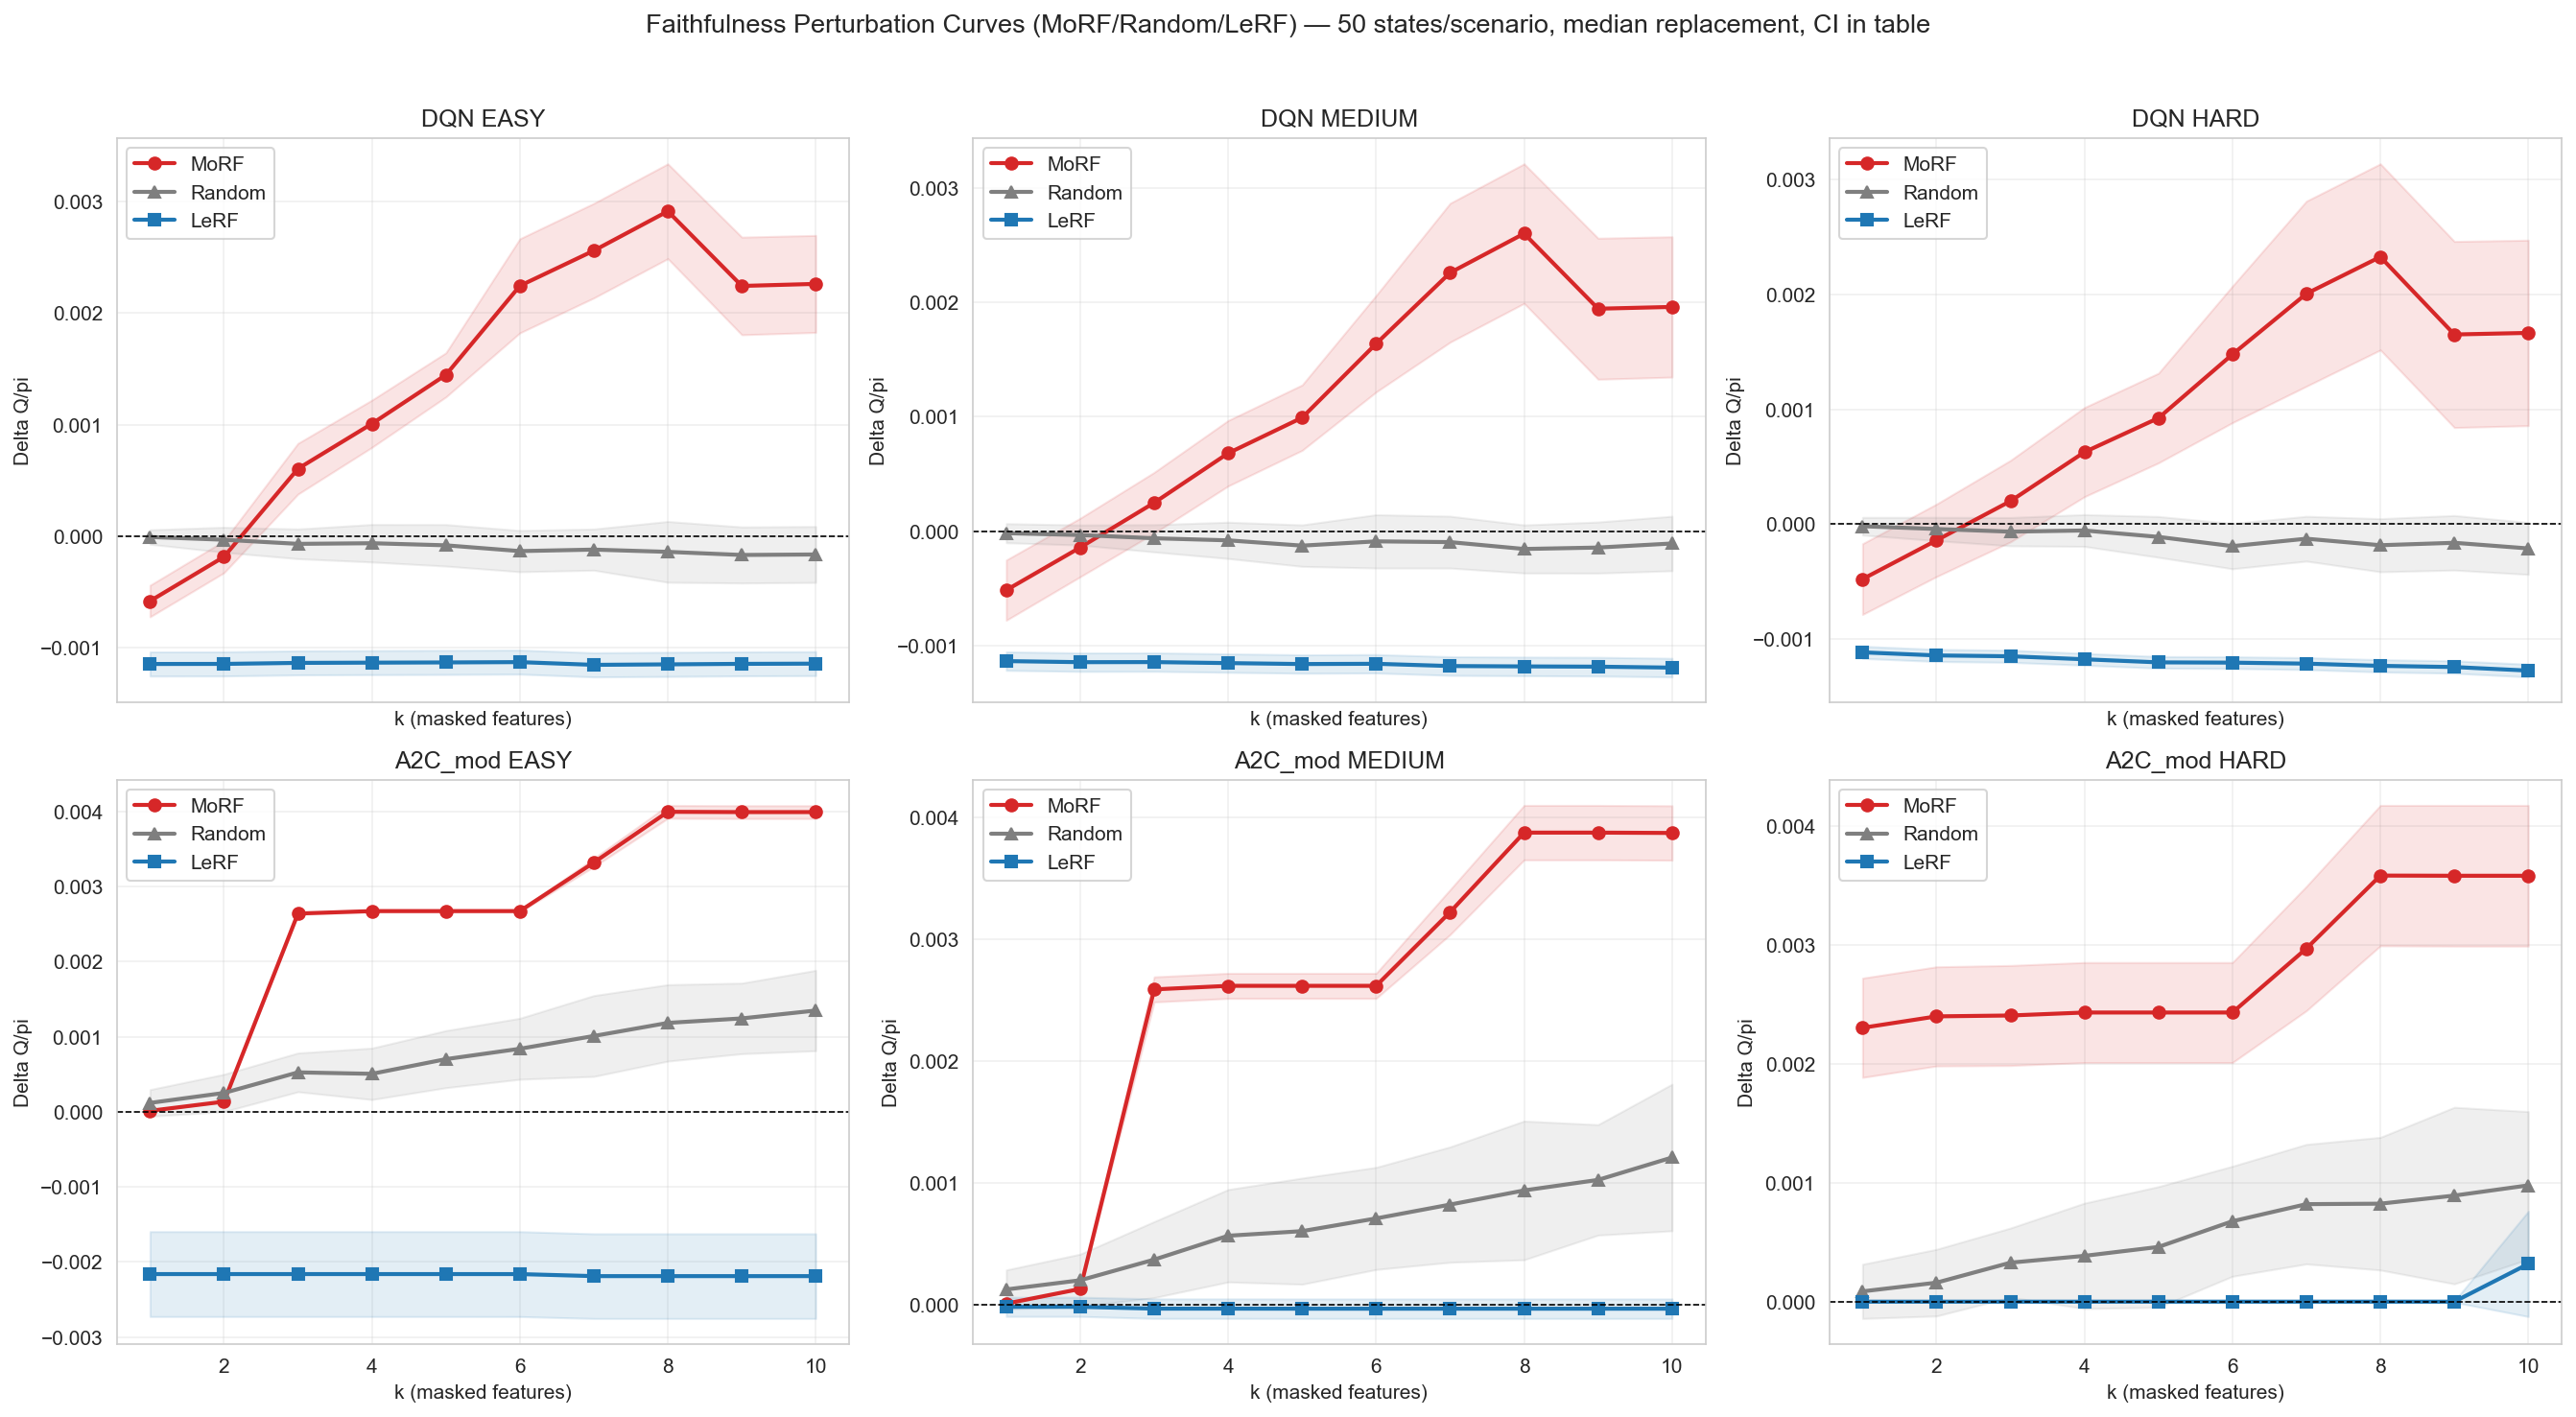

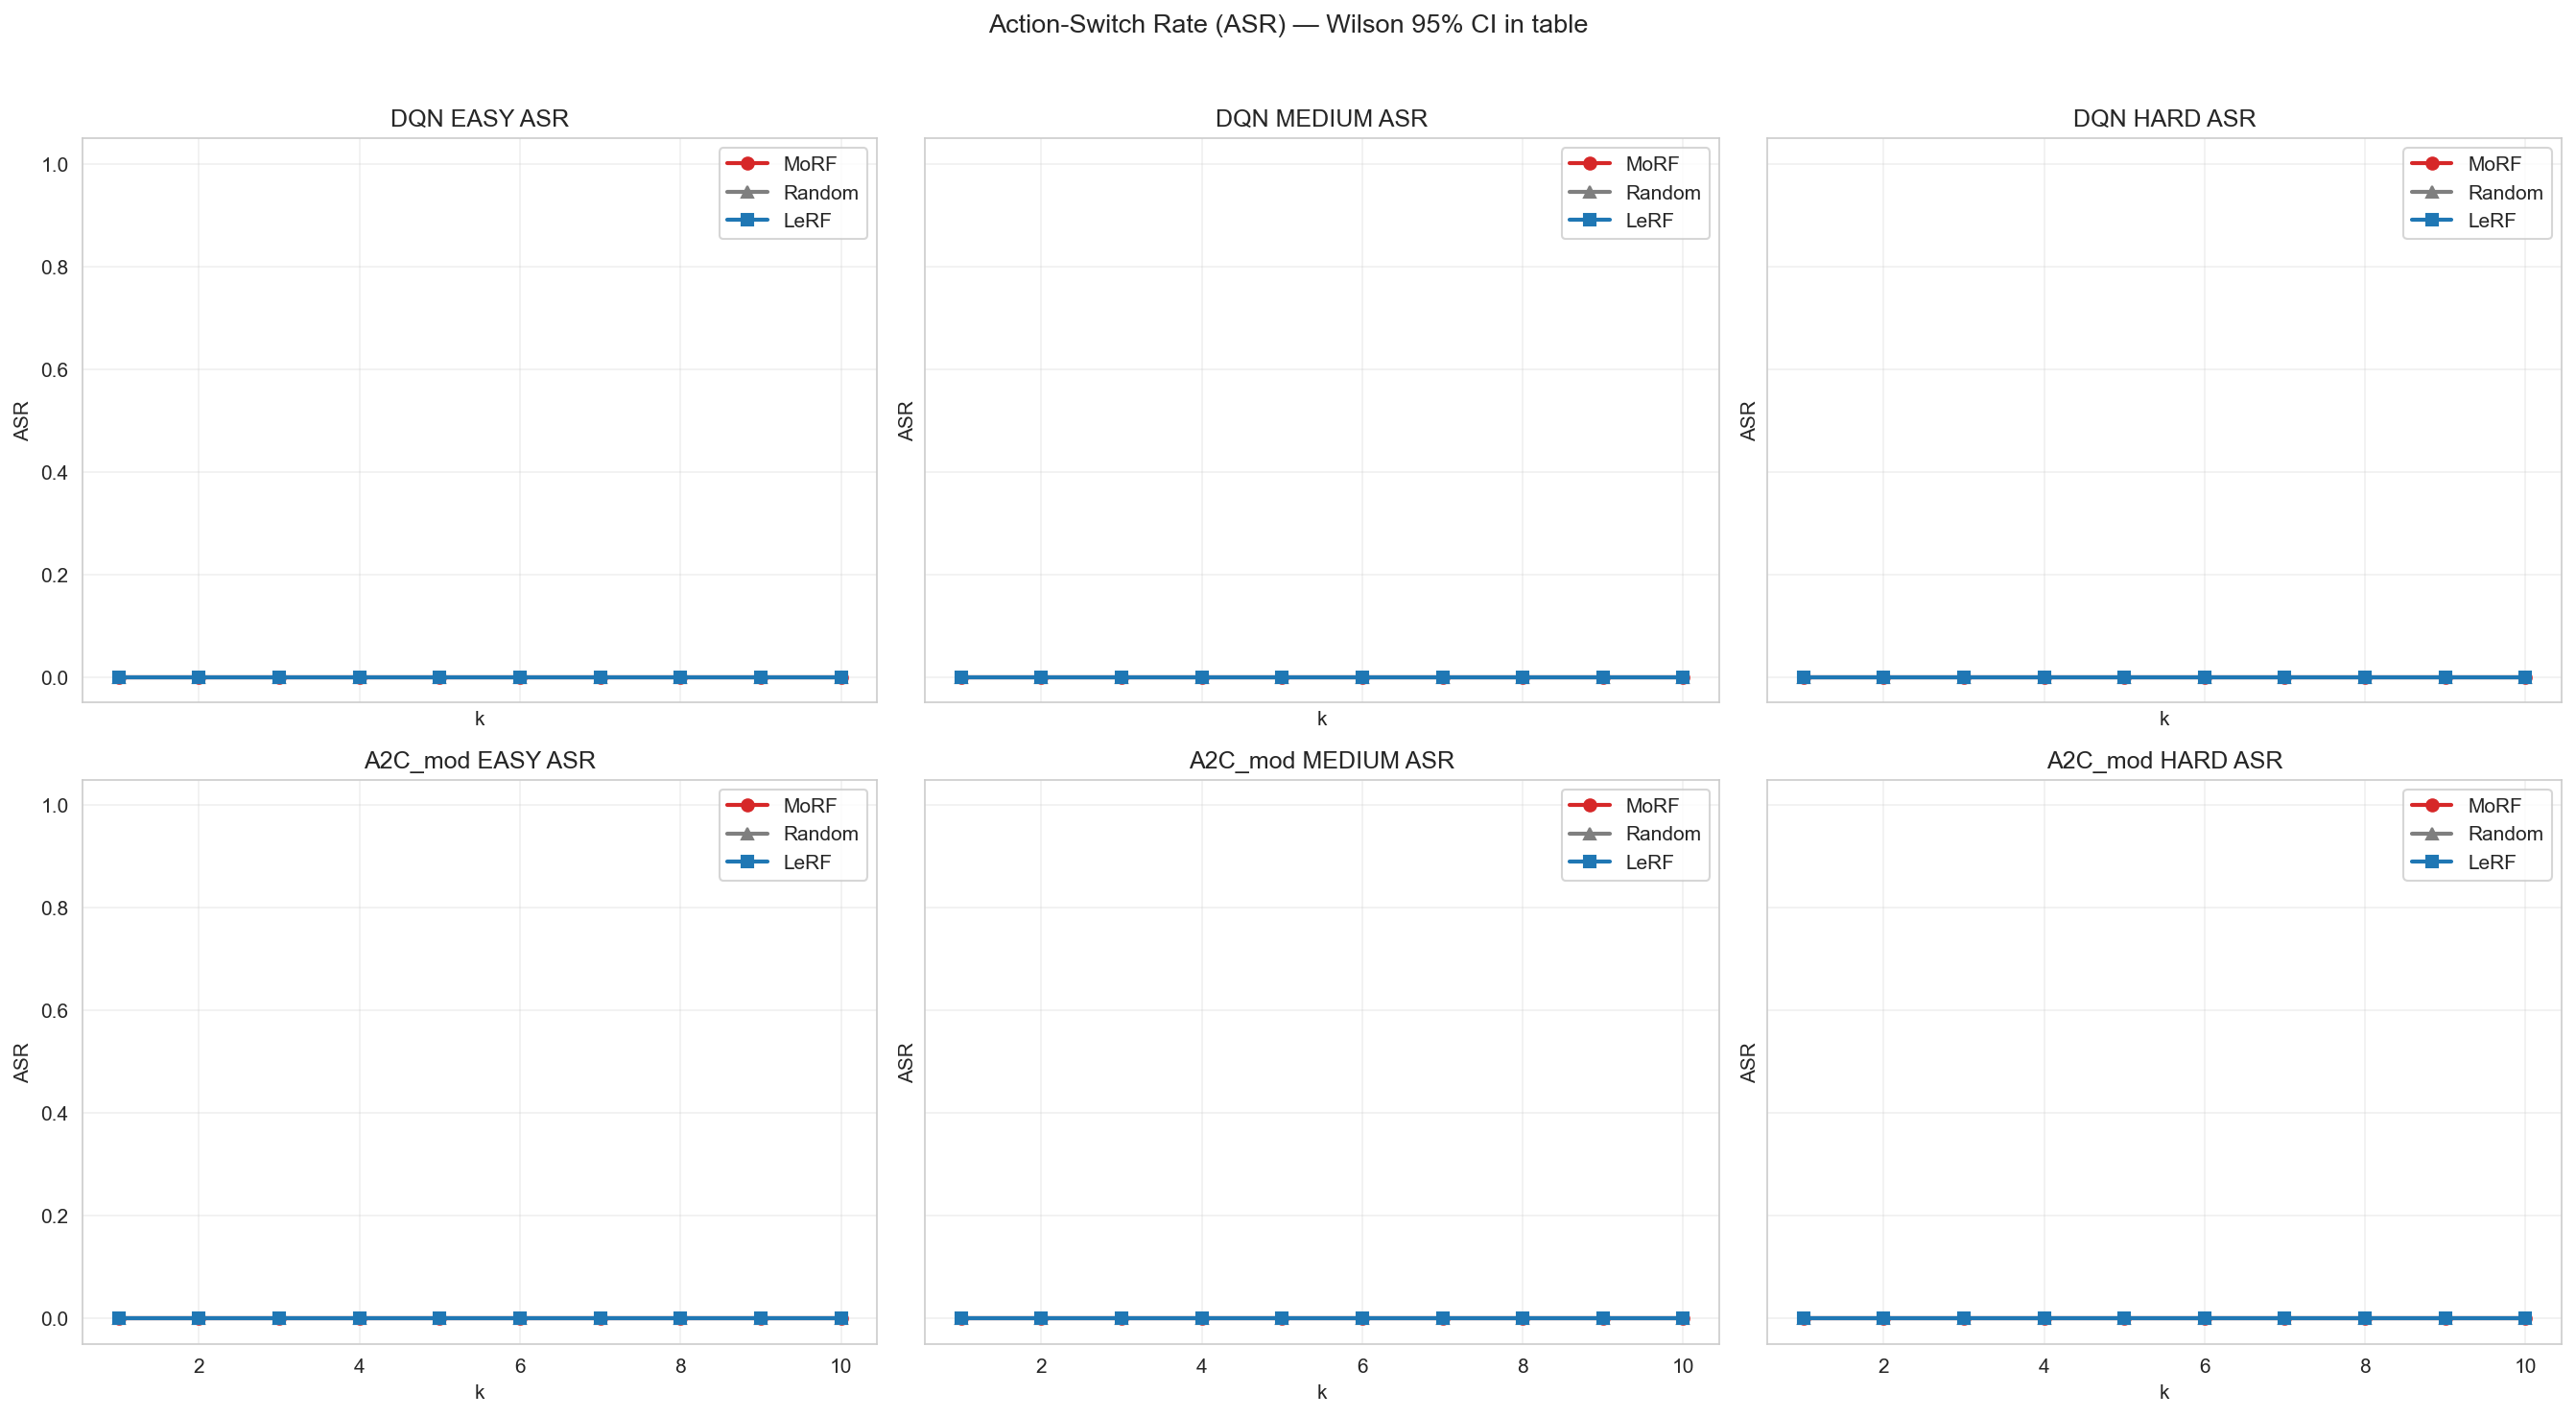

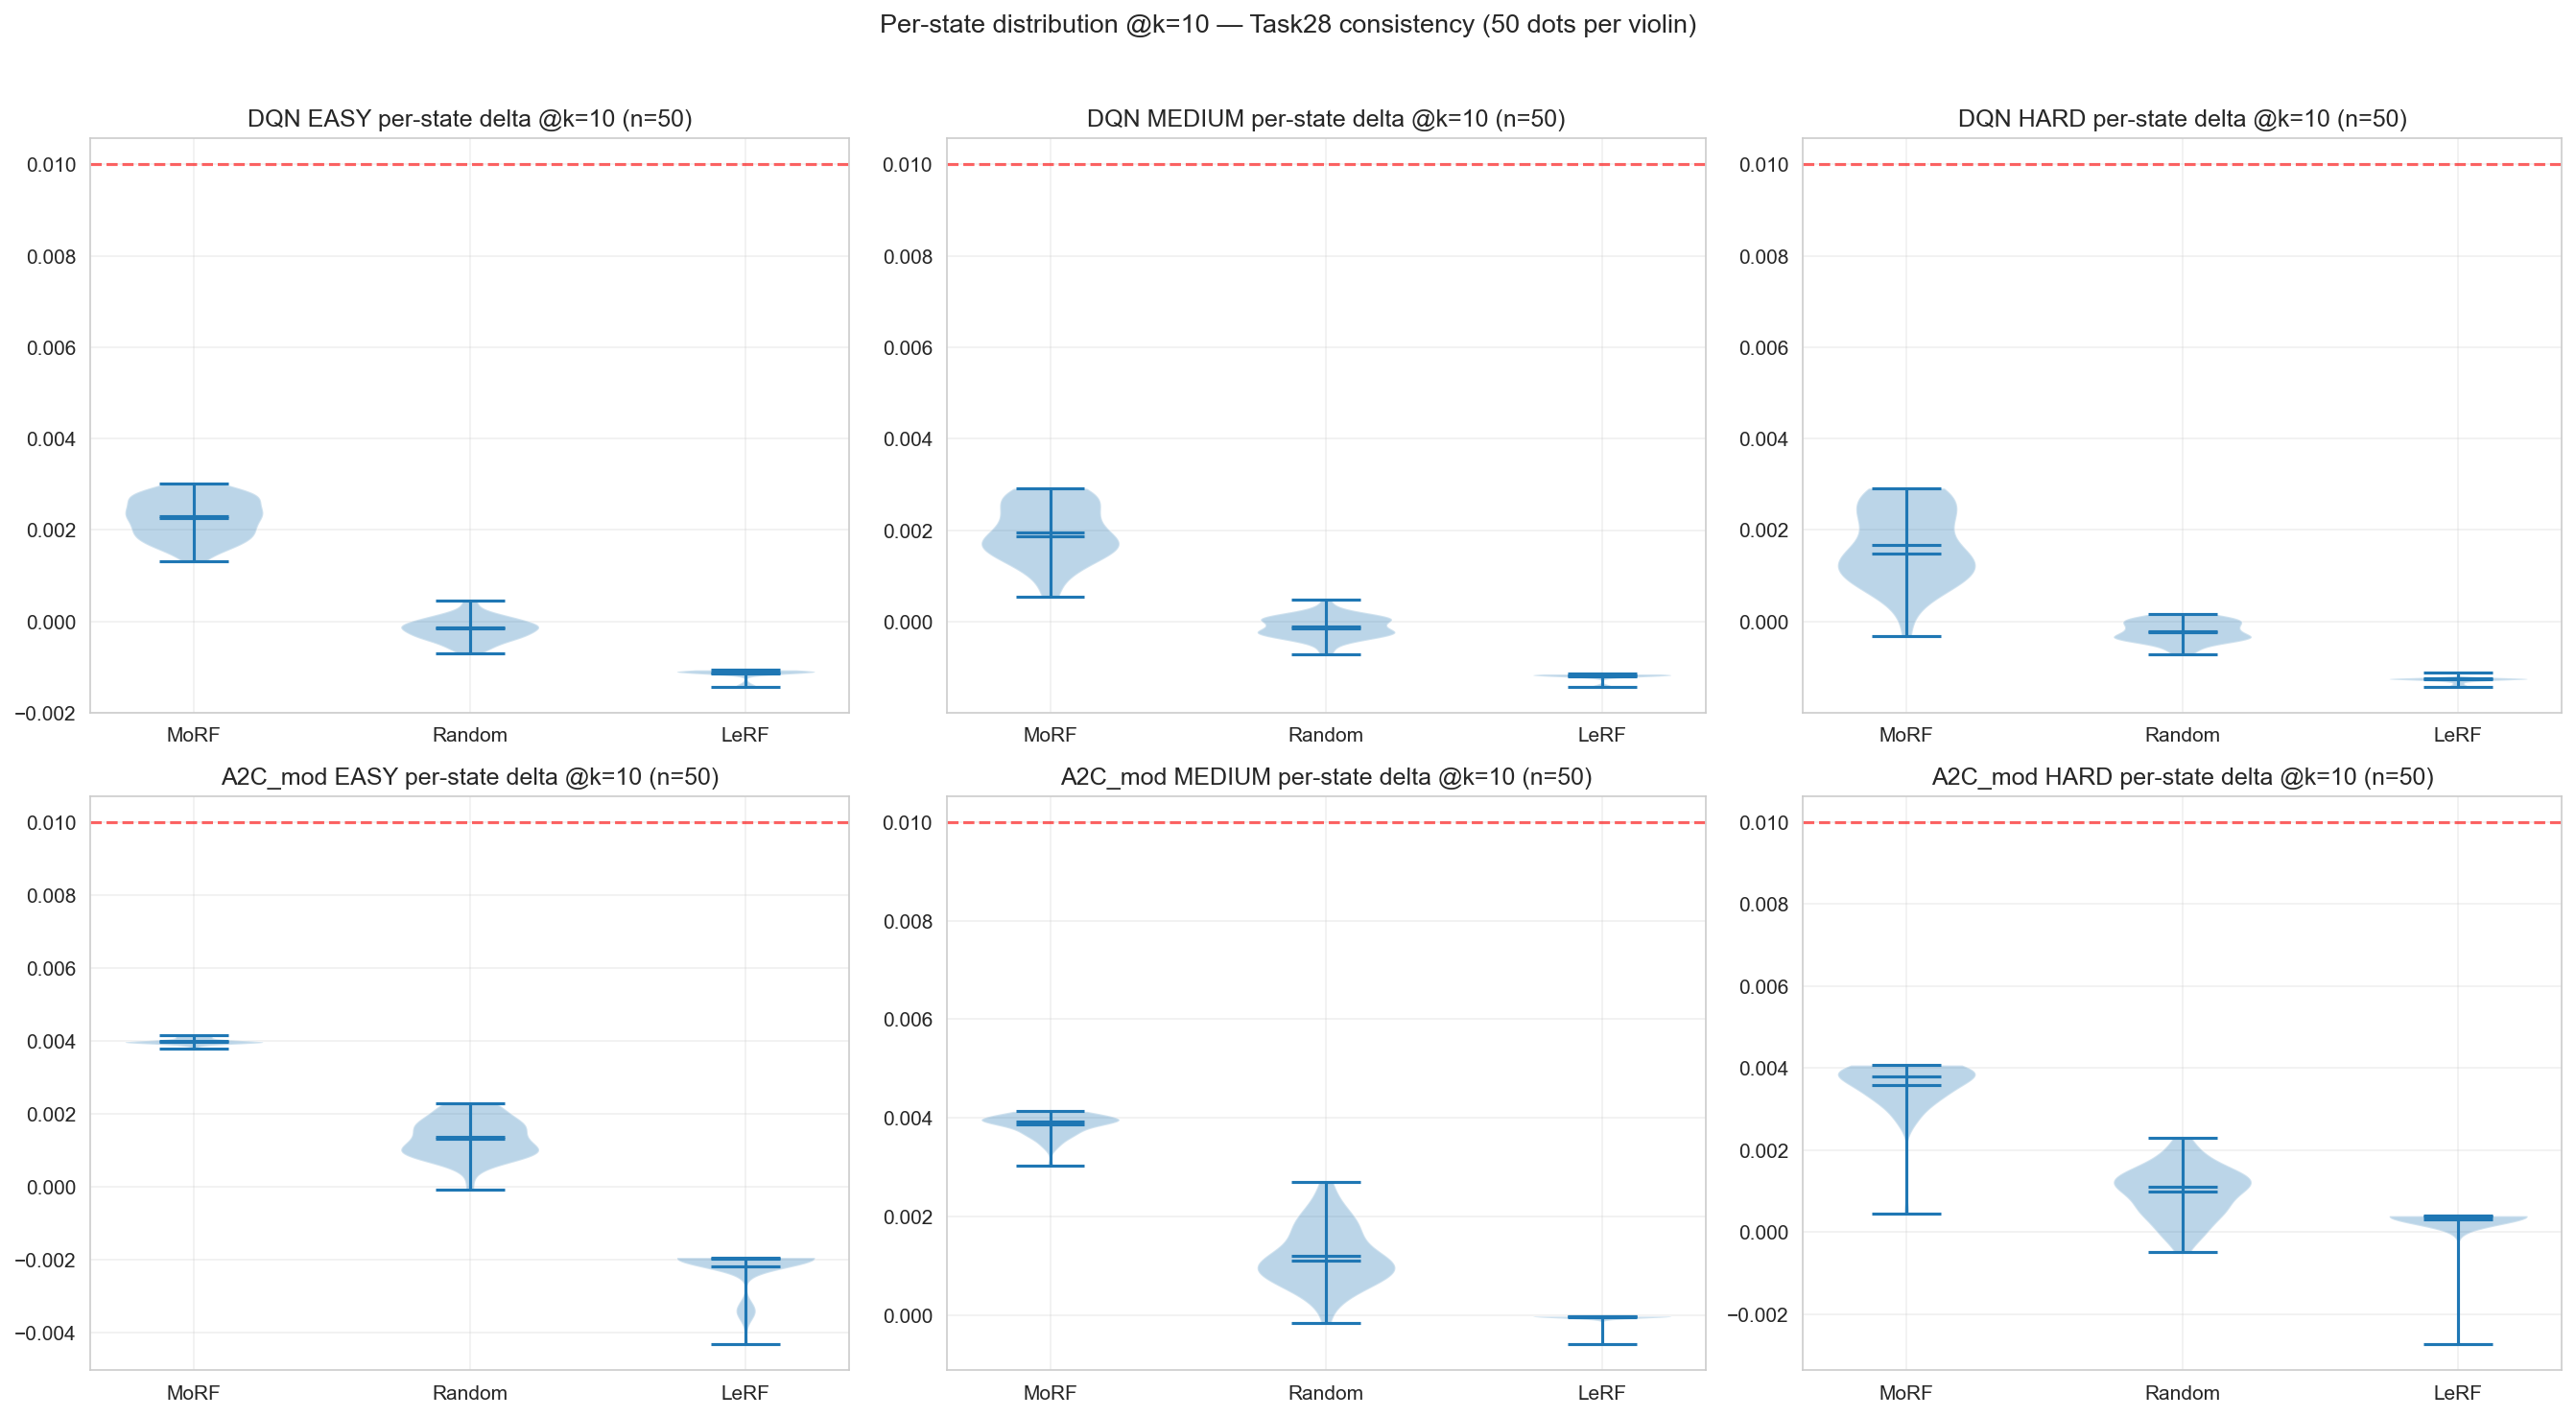

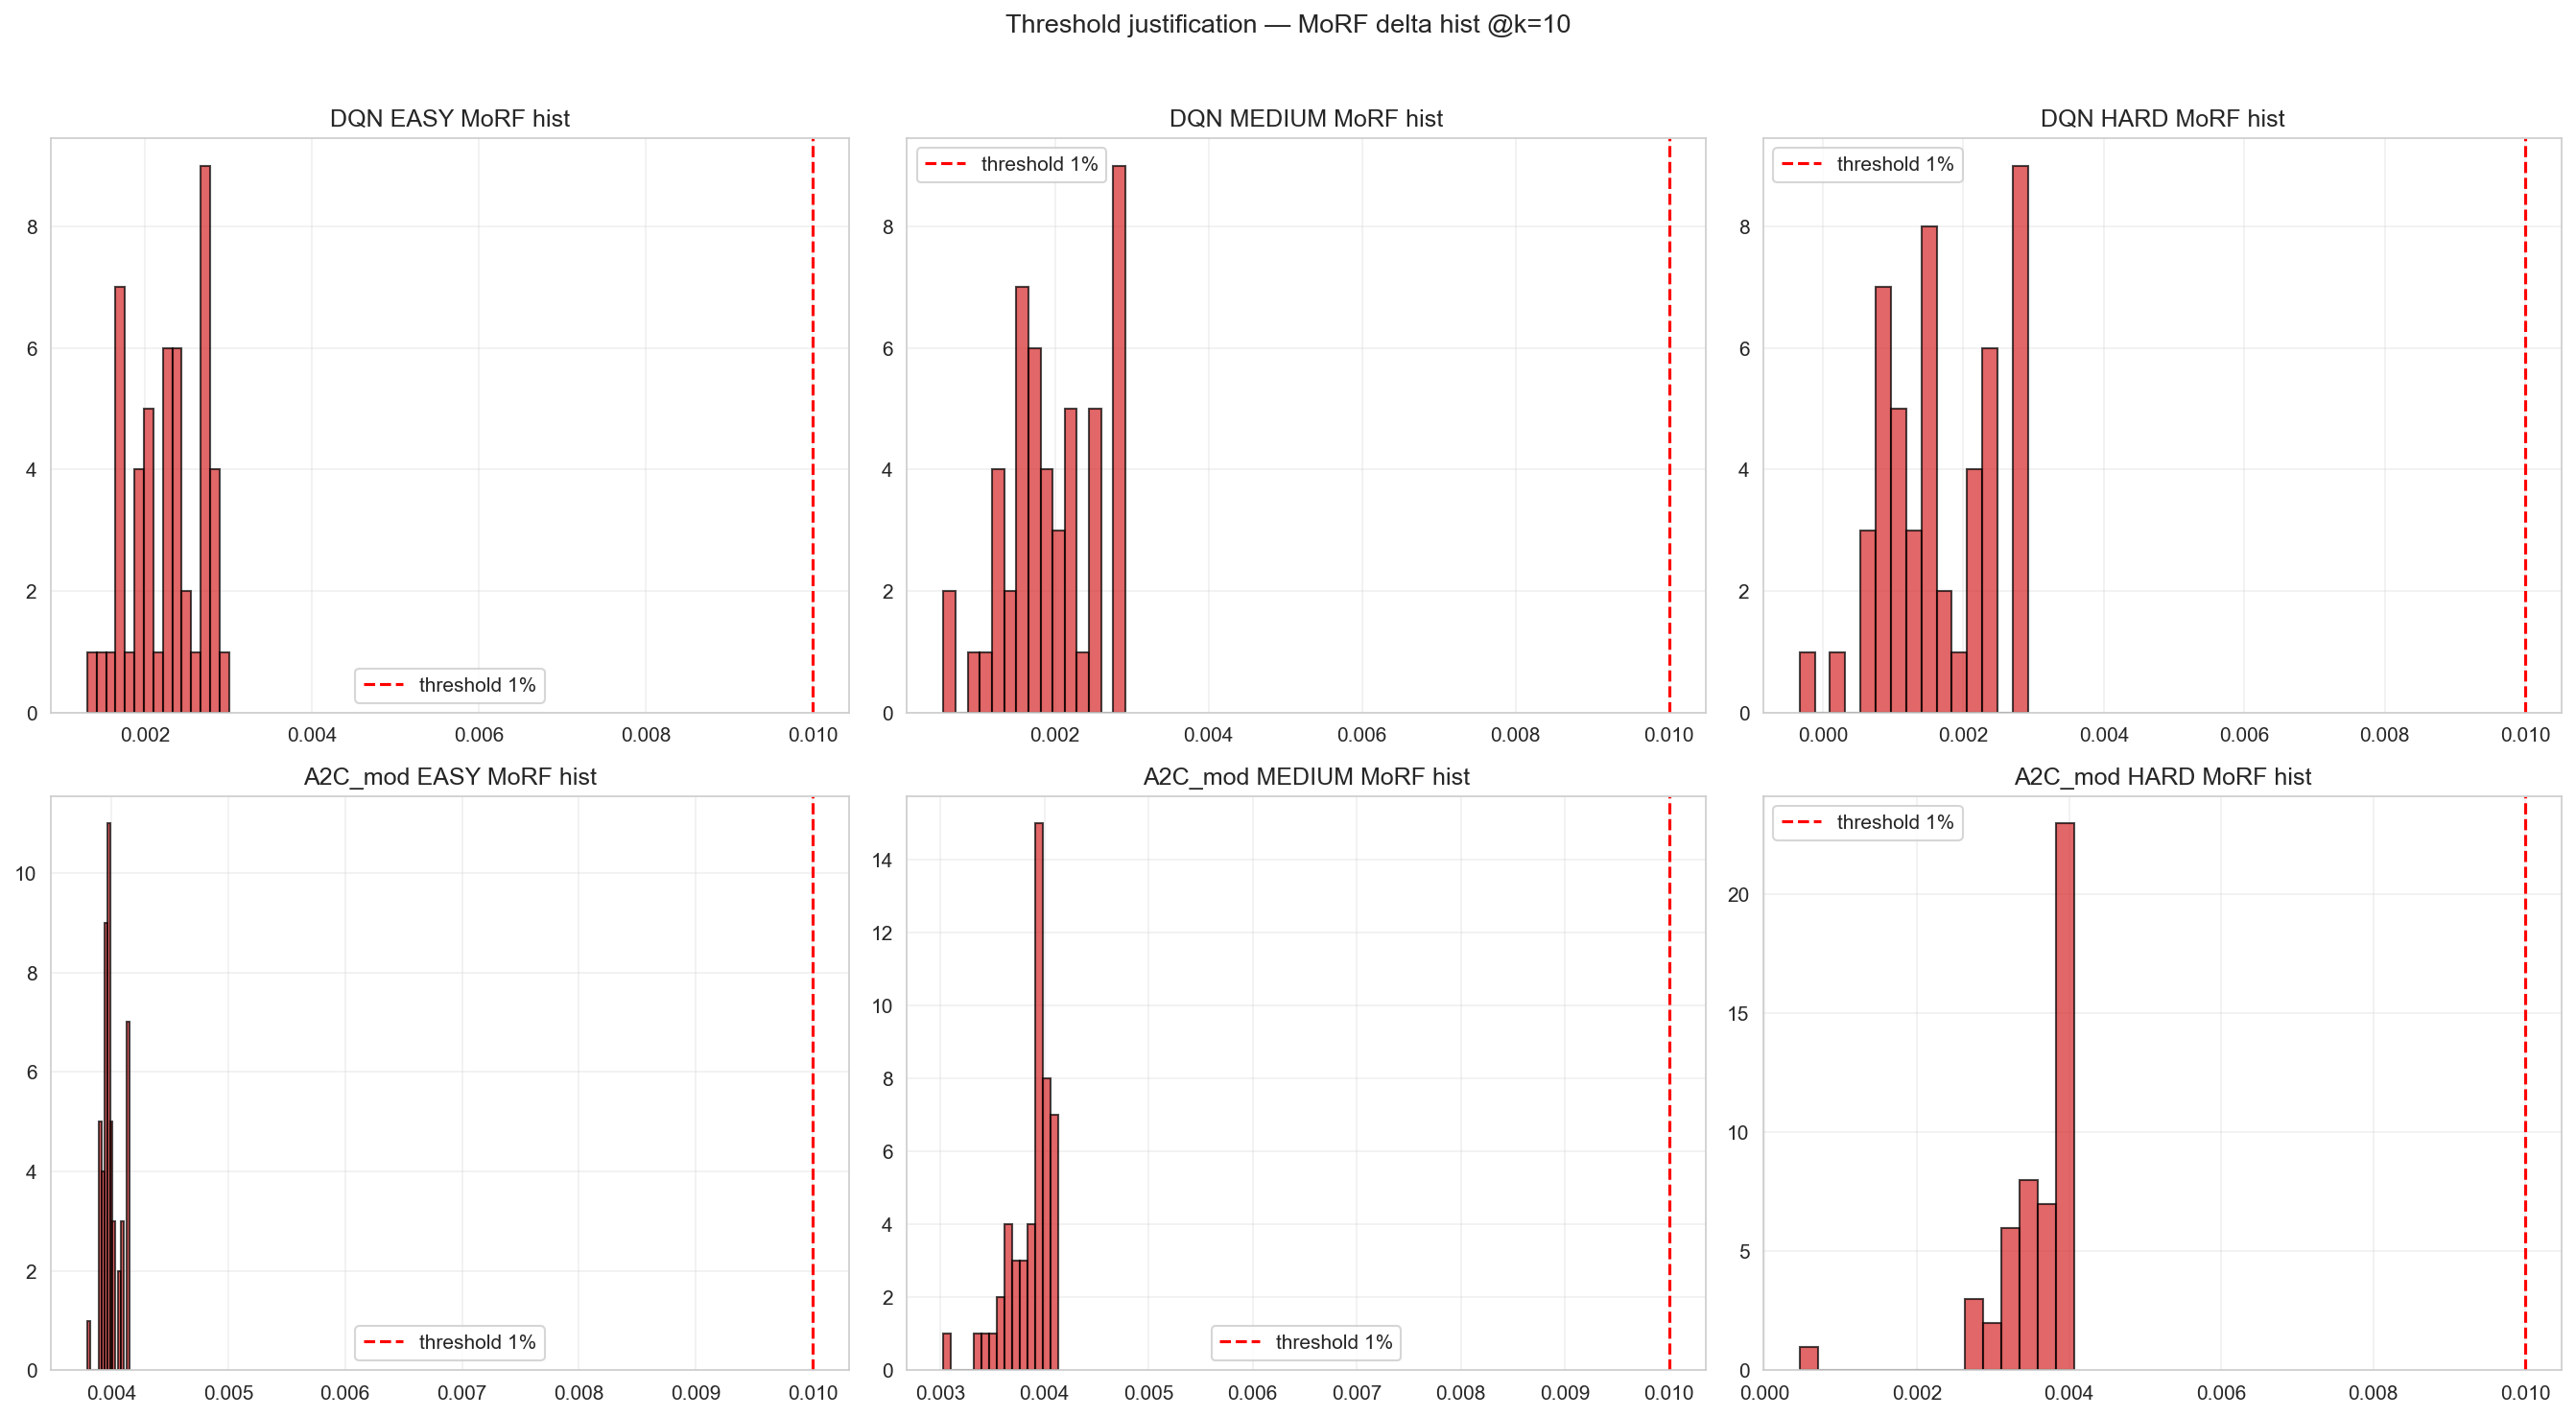

4 figures saved


In [16]:
# Cell 15: Figures THAT — 4 PNG voi CI that
import matplotlib
matplotlib.rcParams['figure.dpi']=150
# Fig1: Perturbation curves with 95% CI (shaded)
fig, axes=plt.subplots(2,3, figsize=(18,10), sharex=True, sharey=False)
ks=np.arange(1,11)
for i, agent in enumerate(AGENTS):
    for j, sc in enumerate(SCENARIO_ORDER):
        ax=axes[i,j]
        for strat, col, mk in [('MoRF','#D62728','o'),('Random','#7F7F7F','^'),('LeRF','#1F77B4','s')]:
            means=np.array([results[agent][sc][strat][k]['mean_delta'] for k in ks])
            # CI band via per-state bootstrap already, hien thi lo/hi o k=5,10
            ax.plot(ks, means, marker=mk, color=col, label=strat, linewidth=2)
            # shaded approx using std for visual, CI chinh trong bang
            stds=np.array([results[agent][sc][strat][k]['std_delta'] for k in ks])
            ax.fill_between(ks, means-stds, means+stds, color=col, alpha=0.12)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f"{agent} {sc}")
        ax.set_xlabel('k (masked features)'); ax.set_ylabel('Delta Q/pi')
        ax.grid(alpha=0.3); ax.legend()
fig.suptitle('Faithfulness Perturbation Curves (MoRF/Random/LeRF) — 50 states/scenario, median replacement, CI in table', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(TASK_OUT/'task15-9_perturbation_with_CI.png', dpi=300)
plt.savefig(OUT_DIR/'task15-9_perturbation_with_CI.png', dpi=300)
plt.show()

# Fig2: ASR curves with Wilson CI
fig, axes=plt.subplots(2,3, figsize=(18,10), sharex=True, sharey=True)
for i, agent in enumerate(AGENTS):
    for j, sc in enumerate(SCENARIO_ORDER):
        ax=axes[i,j]
        for strat, col, mk in [('MoRF','#D62728','o'),('Random','#7F7F7F','^'),('LeRF','#1F77B4','s')]:
            asr=np.array([results[agent][sc][strat][k]['asr'] for k in ks])
            ax.plot(ks, asr, marker=mk, color=col, label=strat, linewidth=2)
        ax.set_title(f"{agent} {sc} ASR"); ax.set_ylim(-0.05,1.05); ax.grid(alpha=0.3); ax.legend()
        ax.set_xlabel('k'); ax.set_ylabel('ASR')
fig.suptitle('Action-Switch Rate (ASR) — Wilson 95% CI in table', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(TASK_OUT/'task15-9_asr_with_CI.png', dpi=300)
plt.savefig(OUT_DIR/'task15-9_asr_with_CI.png', dpi=300)
plt.show()

# Fig3: Per-state violin (Task28)
fig, axes=plt.subplots(2,3, figsize=(18,10))
for i, agent in enumerate(AGENTS):
    for j, sc in enumerate(SCENARIO_ORDER):
        ax=axes[i,j]
        data=[per_state[agent][sc][s][10] for s in ['MoRF','Random','LeRF']]
        parts=ax.violinplot(data, showmeans=True, showmedians=True)
        ax.set_xticks([1,2,3]); ax.set_xticklabels(['MoRF','Random','LeRF'])
        ax.set_title(f"{agent} {sc} per-state delta @k=10 (n=50)")
        ax.axhline(MEANINGFUL_REL_Q, color='red', linestyle='--', alpha=0.6, label='1% threshold')
        ax.grid(alpha=0.3)
fig.suptitle('Per-state distribution @k=10 — Task28 consistency (50 dots per violin)', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(TASK_OUT/'task15-9_per_state_violin.png', dpi=300)
plt.savefig(OUT_DIR/'task15-9_per_state_violin.png', dpi=300)
plt.show()

# Fig4: Threshold hist (Task27)
fig, axes=plt.subplots(2,3, figsize=(18,10))
for i, agent in enumerate(AGENTS):
    for j, sc in enumerate(SCENARIO_ORDER):
        ax=axes[i,j]
        arr=np.array(per_state[agent][sc]['MoRF'][10])
        ax.hist(arr, bins=15, color='#D62728', alpha=0.7, edgecolor='black')
        ax.axvline(MEANINGFUL_REL_Q, color='red', linestyle='--', label='threshold 1%')
        ax.set_title(f"{agent} {sc} MoRF hist"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Threshold justification — MoRF delta hist @k=10', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(TASK_OUT/'task15-9_threshold_hist.png', dpi=300)
plt.savefig(OUT_DIR/'task15-9_threshold_hist.png', dpi=300)
plt.show()
print('4 figures saved')


In [17]:
# Cell 16: Tong hop & in bang de paste vao paper (Vietnamese + Academic English)
print('='*80)
print('TASK 24 — Faithfulness statistics (AUPC/ASR/CI) — that checkpoint')
print(df_stats.round(4).to_string(index=False))
print('\nTASK 25 — Stats MoRF vs Random vs LeRF (Holm):')
print(df_tests[['Agent','Scenario','Comparison','k','p_wilcoxon','p_wilcoxon_holm','cohens_d']].round(4).to_string(index=False))
print('\nMSX-guided vs Random:')
print(df_msx.round(4).to_string(index=False))
print('\nTASK 26 — Protocol: 50 states/scenario (300 total), k=1..10 (0.15-1.52%), median(background 100), B=30, seed 42')
print(f"Checkpoints that: DQN {DQN_CKPT_DIR}/ckpt-50, A2C {A2C_CKPT_DIR}/ckpt-64, hidden DQN={agents['dqn_hidden']}")
print('TASK 27 — Threshold: relative 1% or pi 0.01 or action flip; meaningful_rate in threshold_analysis.csv')
print('TASK 28 — Consistency: CV/IQR/KW in episode_consistency.csv + violin')
print('Output that da luu:')
for p in sorted(TASK_OUT.glob('task15-9_*')): print(' ', p)
for p in sorted(OUT_DIR.glob('task15-9_*')): print(' ', p)
print('='*80)


TASK 24 — Faithfulness statistics (AUPC/ASR/CI) — that checkpoint
  Agent Scenario Strategy    AUPC  AUPC_norm  AUPC_ASR  AUPC_CI_low  AUPC_CI_high  delta_k1  delta_k5  delta_k10  delta_k5_CI_low  delta_k5_CI_high  delta_k10_CI_low  delta_k10_CI_high  ASR_k10  ASR_CI_low  ASR_CI_high  delta_k10_std
    DQN     EASY     MoRF  0.0137     0.0015       0.0       0.0130        0.0144   -0.0006    0.0014     0.0023           0.0014            0.0015            0.0021             0.0024      0.0         0.0       0.0713         0.0004
    DQN     EASY   Random -0.0009    -0.0001       0.0      -0.0011       -0.0007   -0.0000   -0.0001    -0.0002          -0.0001           -0.0000           -0.0002            -0.0001      0.0         0.0       0.0713         0.0003
    DQN     EASY     LeRF -0.0103    -0.0011       0.0      -0.0106       -0.0100   -0.0011   -0.0011    -0.0011          -0.0012           -0.0011           -0.0012            -0.0011      0.0         0.0       0.0713         0.000